# Introduction to Machine Learning: Unsupervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 4: Hierarchical Clustering

---

In this lab, you will explore **Hierarchical Clustering**, a powerful
unsupervised learning technique that builds a tree of nested clusters
called a dendrogram. You will work with the **Iris dataset**, the same
dataset used in Week 3 for K-Means, enabling direct comparison between
the two clustering approaches.

You will:
- Compute linkage matrices using scipy's hierarchical clustering functions
- Visualize dendrograms to understand cluster structure
- Compare different linkage criteria (single, complete, average)
- Cut dendrograms at different heights to extract cluster assignments
- Profile and interpret the resulting clusters
- Compare hierarchical clustering results with K-Means
- Create a reusable function for hierarchical clustering analysis

These skills are essential for exploratory data analysis, especially when
you want to understand nested structure or when the number of clusters
is not known in advance.

## Setup (do not edit)

In [2]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("iris.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "iris.csv is missing from the lab directory. Please run the download "
        "script (w4_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load the Dataset *(10 points)*

Load the Iris dataset from `iris.csv` into a pandas DataFrame.

This is the same Iris dataset you used in Week 3 for K-Means clustering.
Using the same data allows us to directly compare hierarchical clustering
results with K-Means results.

Store the following in the required variables:
- **`q1_shape`**: A tuple containing the shape of the DataFrame `(n_samples, n_features)`
- **`q1_columns`**: A list of all column names (feature names)
- **`q1_n_samples`**: An integer representing the number of samples

In [4]:
# Grade Cell: Question 1
#
# Task: Load the Iris dataset and explore its structure
#
# Instructions:
# 1. Read the CSV file using pd.read_csv()
# 2. Store the shape as a tuple in q1_shape
# 3. Store the column names as a list in q1_columns
# 4. Store the number of samples (rows) as an integer in q1_n_samples

df = pd.read_csv(_DATA_PATH)

q1_shape = df.shape
q1_columns = df.columns.tolist()
q1_n_samples = df.shape[0]

In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(
    q1_shape, tuple
), "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (n_samples, n_features). "
    "Make sure you're using .shape, not .shape[0]."
)
assert (
    q1_shape[0] > 0 and q1_shape[1] > 0
), "Shape values must be positive. Is your CSV loading correctly?"
assert isinstance(
    q1_columns, list
), "q1_columns must be a list. Use df.columns.tolist() to convert."
assert (
    len(q1_columns) == q1_shape[1]
), "Number of columns in q1_columns should match q1_shape[1]."
assert isinstance(q1_n_samples, int), "q1_n_samples must be an integer."
print(f"Dataset shape: {q1_shape}")
print(f"Number of samples: {q1_n_samples}")
print(f"Features: {q1_columns}")

Dataset shape: (150, 4)
Number of samples: 150
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 2. Standardize the Data *(10 points)*

Just like with K-Means, standardization is crucial for hierarchical clustering
because it uses distance calculations. Features with larger scales would
dominate the distance calculations otherwise.

Apply **z-score standardization** to the data using `StandardScaler`:
$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Store the results as:
- **`q2_scaled_data`**: A numpy array of the standardized data
- **`q2_scaled_means`**: A numpy array of column means of the scaled data (should all be ~0)
- **`q2_scaled_stds`**: A numpy array of column stds of the scaled data (should all be ~1)

In [7]:
# Grade Cell: Question 2
#
# Task: Standardize the data using StandardScaler
#
# Instructions:
# 1. Create a StandardScaler instance
# 2. Fit and transform the data (df.values or df as input)
# 3. Compute the column means and stds of the scaled data to verify

scaler = StandardScaler()
q2_scaled_data = scaler.fit_transform(df.values)

q2_scaled_means = q2_scaled_data.mean(axis = 0)
q2_scaled_stds = q2_scaled_data.std(axis = 0)

In [8]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_scaled_data, np.ndarray), "q2_scaled_data must be a numpy array."
assert (
    q2_scaled_data.shape == q1_shape
), f"Scaled data should have same shape as original: {q1_shape}."
assert isinstance(q2_scaled_means, np.ndarray), "q2_scaled_means must be a numpy array."
assert isinstance(q2_scaled_stds, np.ndarray), "q2_scaled_stds must be a numpy array."
# Check that all means are approximately 0
assert np.allclose(q2_scaled_means, 0, atol=0.01), (
    "After standardization, all feature means should be ~0. "
    "Did you use StandardScaler correctly?"
)
# Check that all stds are approximately 1
assert np.allclose(q2_scaled_stds, 1, atol=0.01), (
    "After standardization, all feature stds should be ~1. "
    "Did you use StandardScaler correctly?"
)
print(f"Scaled data shape: {q2_scaled_data.shape}")
print(f"Scaled means (should be ~0): {q2_scaled_means}")
print(f"Scaled stds (should be ~1): {q2_scaled_stds}")

Scaled data shape: (150, 4)
Scaled means (should be ~0): [-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
Scaled stds (should be ~1): [1. 1. 1. 1.]


## 3. Compute Linkage Matrix *(10 points)*

The first step in hierarchical clustering is computing the **linkage matrix**.
This matrix encodes the merge history: which clusters were merged at each step
and the distance at which they merged.

Use scipy's `linkage()` function with **complete linkage** (also called
"furthest neighbor" linkage), which defines the distance between two clusters
as the maximum distance between any pair of their members.

Store the results as:
- **`q3_linkage_matrix`**: The linkage matrix (numpy array) from scipy
- **`q3_n_merges`**: The number of merges performed (integer)
- **`q3_max_distance`**: The maximum merge distance (float, rounded to 2 decimals)

In [9]:
# Grade Cell: Question 3
#
# Task: Compute the linkage matrix using complete linkage
#
# Instructions:
# 1. Use scipy.cluster.hierarchy.linkage() with method='complete'
# 2. The number of merges equals n_samples - 1
# 3. The maximum distance is in the last row, third column of the linkage matrix

q3_linkage_matrix = linkage(q2_scaled_data, method = 'complete')

q3_n_merges = q3_linkage_matrix.shape[0]
q3_max_distance = round(float(q3_linkage_matrix[-1, 2]), 2)

In [10]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(
    q3_linkage_matrix, np.ndarray
), "q3_linkage_matrix must be a numpy array."
assert q3_linkage_matrix.shape[1] == 4, (
    "Linkage matrix should have 4 columns: "
    "[cluster_i, cluster_j, distance, n_observations]."
)
assert isinstance(q3_n_merges, int), "q3_n_merges must be an integer."
assert q3_n_merges == q1_n_samples - 1, (
    f"Number of merges should be n_samples - 1 = {q1_n_samples - 1}. "
    "Each merge combines two clusters, ending with one cluster."
)
assert isinstance(q3_max_distance, float), "q3_max_distance must be a float."
assert q3_max_distance > 0, "Maximum merge distance must be positive."
print(f"Linkage matrix shape: {q3_linkage_matrix.shape}")
print(f"Number of merges: {q3_n_merges}")
print(f"Maximum merge distance: {q3_max_distance}")

Linkage matrix shape: (149, 4)
Number of merges: 149
Maximum merge distance: 6.53


## 4. Visualize Dendrogram *(10 points)*

A **dendrogram** is a tree diagram that visualizes the hierarchical clustering
process. The y-axis shows the distance (dissimilarity) at which clusters merge.
Observations are shown at the bottom, and merges are shown as horizontal lines
connecting branches.

Create a dendrogram using scipy's `dendrogram()` function.

Store the results as:
- **`q4_dendrogram`**: The dictionary returned by scipy's dendrogram() function
- **`q4_n_leaves`**: The number of leaves in the dendrogram (should equal n_samples)
- **`q4_plot_created`**: Set to True after creating the dendrogram plot

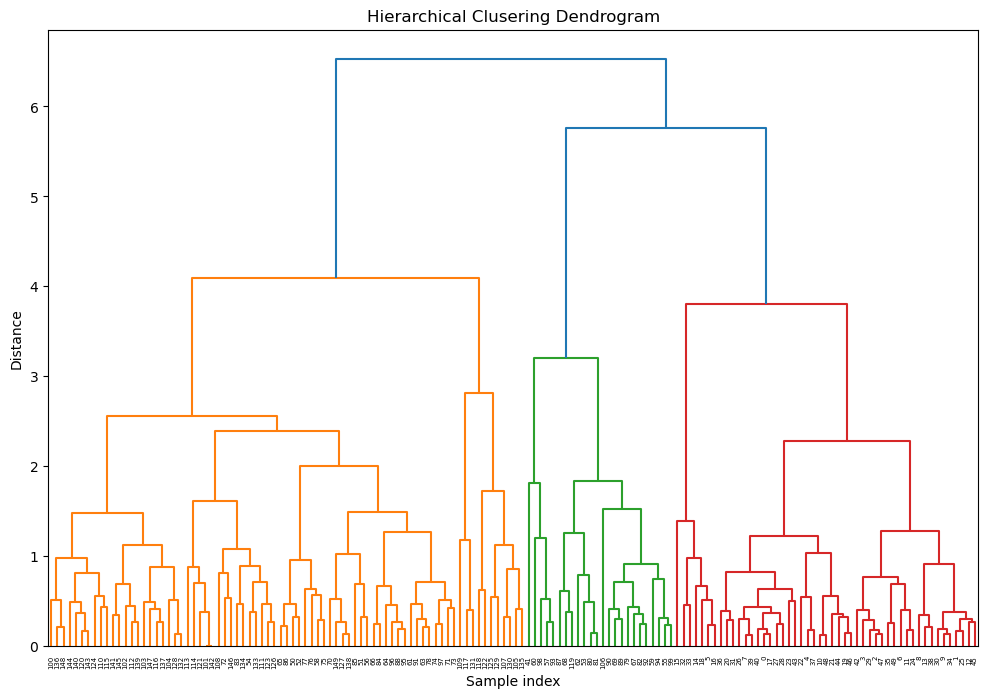

In [13]:
# Grade Cell: Question 4
#
# Task: Create and visualize a dendrogram
#
# Instructions:
# 1. Create a figure with appropriate size
# 2. Use scipy.cluster.hierarchy.dendrogram() with the linkage matrix
# 3. Add labels and title
# 4. The dendrogram() function returns a dictionary with information about the tree

plt.figure(figsize = (12, 8))
q4_dendrogram = dendrogram(q3_linkage_matrix)
plt.title('Hierarchical Clusering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

q4_n_leaves = len(q4_dendrogram['leaves'])
q4_plot_created = True

In [15]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(q4_dendrogram, dict), "q4_dendrogram must be a dictionary."
assert "leaves" in q4_dendrogram, (
    "The dendrogram dictionary should contain 'leaves'. "
    "Did you call scipy.cluster.hierarchy.dendrogram()?"
)
assert "icoord" in q4_dendrogram and "dcoord" in q4_dendrogram, (
    "The dendrogram dictionary should contain 'icoord' and 'dcoord' for plotting."
)
assert isinstance(q4_n_leaves, int), "q4_n_leaves must be an integer."
assert q4_n_leaves == q1_n_samples, (
    f"Number of leaves should equal n_samples ({q1_n_samples}). "
    "Each sample should be a leaf in the dendrogram."
)
assert q4_plot_created is True, "Set q4_plot_created to True after creating the plot."
print(f"Number of leaves in dendrogram: {q4_n_leaves}")
print(f"Dendrogram keys: {list(q4_dendrogram.keys())}")

Number of leaves in dendrogram: 150
Dendrogram keys: ['icoord', 'dcoord', 'ivl', 'leaves', 'color_list', 'leaves_color_list']


## 5. Compare Linkage Criteria *(10 points)*

Different linkage criteria produce different dendrograms. The three main
linkage methods are:

- **Single linkage**: Distance = minimum distance between any pair of members
- **Complete linkage**: Distance = maximum distance between any pair of members
- **Average linkage**: Distance = average of all pairwise distances

Compute linkage matrices for all three methods and compare the maximum
merge distances.

Store the results as:
- **`q5_linkage_single`**: Linkage matrix using single linkage
- **`q5_linkage_complete`**: Linkage matrix using complete linkage
- **`q5_linkage_average`**: Linkage matrix using average linkage
- **`q5_max_distances`**: A dictionary mapping linkage name to max merge distance

In [19]:
# Grade Cell: Question 5
#
# Task: Compute and compare linkage matrices for different methods
#
# Instructions:
# 1. Compute linkage with method='single', 'complete', and 'average'
# 2. Extract the maximum merge distance from each (last row, column index 2)
# 3. Store in a dictionary for comparison

q5_linkage_single = linkage(q2_scaled_data, method = 'single')
q5_linkage_complete = linkage(q2_scaled_data, method = 'complete')
q5_linkage_average = linkage(q2_scaled_data, method = 'average')

q5_max_distances = {
        'single': float(q5_linkage_single[-1, 2]),
        'complete': float(q5_linkage_complete[-1, 2]),
        'average': float(q5_linkage_average[-1, 2])
}



In [20]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(
    q5_linkage_single, np.ndarray
), "q5_linkage_single must be a numpy array."
assert isinstance(
    q5_linkage_complete, np.ndarray
), "q5_linkage_complete must be a numpy array."
assert isinstance(
    q5_linkage_average, np.ndarray
), "q5_linkage_average must be a numpy array."
for name, Z in [
    ("single", q5_linkage_single),
    ("complete", q5_linkage_complete),
    ("average", q5_linkage_average),
]:
    assert Z.shape == (q1_n_samples - 1, 4), (
        f"Linkage matrix for {name} should have shape "
        f"({q1_n_samples - 1}, 4)."
    )
assert isinstance(q5_max_distances, dict), "q5_max_distances must be a dictionary."
assert set(q5_max_distances.keys()) == {"single", "complete", "average"}, (
    "q5_max_distances should have keys 'single', 'complete', 'average'."
)
# Single linkage should have smallest max distance, complete should have largest
assert q5_max_distances["single"] < q5_max_distances["average"] < q5_max_distances["complete"], (
    "Expected: single < average < complete max distances. "
    "Single linkage finds the shortest path; complete finds the longest."
)
print("Maximum merge distances by linkage:")
for name, dist in q5_max_distances.items():
    print(f"  {name}: {dist}")

Maximum merge distances by linkage:
  single: 1.5585630564131665
  complete: 6.5293233125454835
  average: 3.6601333340985196


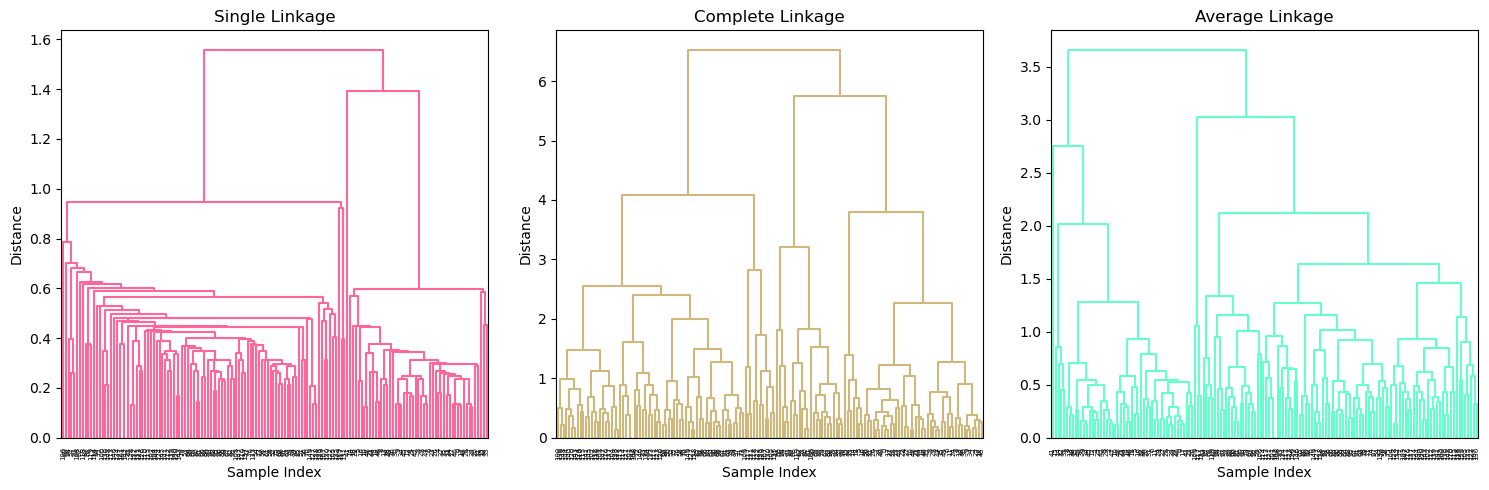

In [21]:
# Visualize the three dendrograms side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

linkage_data = [
    (q5_linkage_single, "Single Linkage", "#FF6699"),
    (q5_linkage_complete, "Complete Linkage", "#CFB87C"),
    (q5_linkage_average, "Average Linkage", "#66FFCC"),
]

for ax, (Z, title, color) in zip(axes, linkage_data):
    dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color=color)
    ax.set_title(title)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

## 6. Cut Dendrogram to Extract Clusters *(10 points)*

To obtain a specific number of clusters, we "cut" the dendrogram at a
chosen height. All branches below the cut belong to the same cluster.

Use scipy's `fcluster()` function to cut the dendrogram and extract
cluster assignments. We'll use the complete linkage dendrogram and
cut it to get exactly 3 clusters (matching the known iris species).

Store the results as:
- **`q6_labels`**: A numpy array of cluster labels (1-indexed) for each sample
- **`q6_n_clusters`**: The number of unique clusters (should be 3)
- **`q6_cluster_counts`**: A dictionary mapping cluster label to sample count

In [22]:
# Grade Cell: Question 6
#
# Task: Cut the dendrogram to extract cluster assignments
#
# Instructions:
# 1. Use scipy.cluster.hierarchy.fcluster() to cut the dendrogram
# 2. Use criterion='maxclust' to specify the number of clusters
# 3. Set t=3 to get 3 clusters
# 4. Count samples per cluster

q6_labels = fcluster(q3_linkage_matrix, t = 3, criterion = 'maxclust')
q6_n_clusters = len(np.unique(q6_labels))
q6_cluster_counts = {int(label): int(count) 
                     for label, count in zip(*np.unique(q6_labels, return_counts = True))}

In [23]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(q6_labels, np.ndarray), "q6_labels must be a numpy array."
assert len(q6_labels) == q1_n_samples, (
    f"q6_labels should have {q1_n_samples} entries, one per sample."
)
# fcluster returns 1-indexed labels by default
assert min(q6_labels) >= 1, (
    "Cluster labels should be 1-indexed (start from 1). "
    "This is the default behavior of fcluster()."
)
assert isinstance(q6_n_clusters, int), "q6_n_clusters must be an integer."
assert q6_n_clusters == 3, (
    f"Expected 3 clusters, got {q6_n_clusters}. "
    "Did you use criterion='maxclust' with t=3?"
)
assert isinstance(q6_cluster_counts, dict), "q6_cluster_counts must be a dictionary."
assert sum(q6_cluster_counts.values()) == q1_n_samples, (
    "Total samples across clusters should equal n_samples."
)
print(f"Cluster labels (first 10): {q6_labels[:10]}")
print(f"Number of clusters: {q6_n_clusters}")
print(f"Samples per cluster: {q6_cluster_counts}")

Cluster labels (first 10): [3 3 3 3 3 3 3 3 3 3]
Number of clusters: 3
Samples per cluster: {1: 77, 2: 24, 3: 49}


## 7. Cluster Profiling *(10 points)*

To interpret clusters, we compute the mean of each feature within each
cluster. This helps us understand what makes each cluster distinct.

Profile the hierarchical clusters by computing feature means per cluster.

Store the results as:
- **`q7_cluster_means`**: A DataFrame with clusters as rows and features as columns
- **`q7_largest_cluster`**: The cluster label with the most samples
- **`q7_cluster_1_dominant_feature`**: The feature name where cluster 1 has the highest mean

In [26]:
# Grade Cell: Question 7
#
# Task: Profile clusters by computing feature means
#
# Instructions:
# 1. Create a DataFrame with standardized data and cluster labels
# 2. Group by cluster and compute mean of each feature
# 3. Find the largest cluster and the dominant feature for cluster 1

q7_cluster_means = pd.DataFrame(q2_scaled_data, columns = q1_columns)
q7_cluster_means['cluster'] = q6_labels
q7_cluster_means = q7_cluster_means.groupby('cluster').mean()

q7_largest_cluster = int(max(q6_cluster_counts, key = q6_cluster_counts.get))

q7_cluster_1_dominant_feature = q7_cluster_means.loc[1].idxmax()

In [27]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(
    q7_cluster_means, pd.DataFrame
), "q7_cluster_means must be a pandas DataFrame."
assert q7_cluster_means.shape[0] == q6_n_clusters, (
    f"q7_cluster_means should have {q6_n_clusters} rows (one per cluster)."
)
assert q7_cluster_means.shape[1] == len(q1_columns), (
    f"q7_cluster_means should have {len(q1_columns)} columns (one per feature)."
)
assert isinstance(q7_largest_cluster, int), (
    "q7_largest_cluster must be an integer (cluster label)."
)
assert 1 <= q7_largest_cluster <= q6_n_clusters, (
    f"q7_largest_cluster should be between 1 and {q6_n_clusters}."
)
assert isinstance(q7_cluster_1_dominant_feature, str), (
    "q7_cluster_1_dominant_feature must be a string (feature name)."
)
assert q7_cluster_1_dominant_feature in q1_columns, (
    "q7_cluster_1_dominant_feature must be one of the original feature names."
)
print("Cluster means (standardized scale):")
print(q7_cluster_means.round(2))
print(f"\nLargest cluster: {q7_largest_cluster}")
print(f"Cluster 1 dominant feature: {q7_cluster_1_dominant_feature}")

Cluster means (standardized scale):
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
cluster                                                           
1                     0.76             -0.15               0.81   
2                    -0.40             -1.36               0.06   
3                    -1.00              0.91              -1.30   

         petal width (cm)  
cluster                    
1                    0.81  
2                   -0.04  
3                   -1.26  

Largest cluster: 1
Cluster 1 dominant feature: petal width (cm)


## 8. Visualize Clusters in PCA Space *(10 points)*

Since our data has 4 features, we can use **PCA** to project the data
to 2 dimensions for visualization. Color the points by their hierarchical
cluster assignments.

Store the results as:
- **`q8_pca`**: A fitted PCA object with 2 components
- **`q8_pca_data`**: A numpy array of shape (n_samples, 2) with the projected data
- **`q8_variance_explained`**: Total variance explained by 2 PCs (float, rounded to 3 decimals)
- **`q8_plot_created`**: Set to True after creating the scatter plot

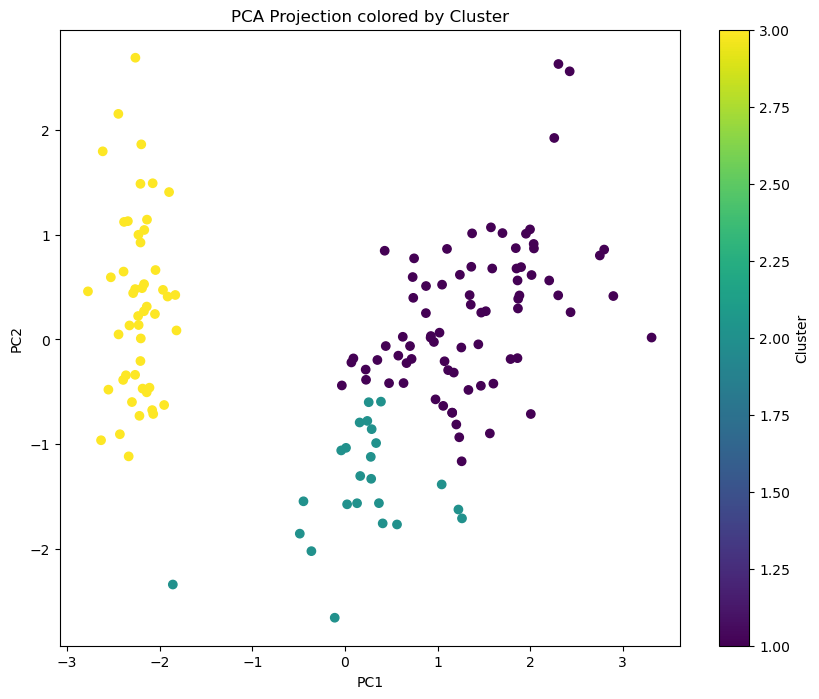

In [28]:
# Grade Cell: Question 8
#
# Task: Visualize hierarchical clusters using PCA projection
#
# Instructions:
# 1. Fit PCA with n_components=2 to the standardized data
# 2. Transform the data to 2D
# 3. Create a scatter plot colored by cluster labels (q6_labels)
# 4. Compute total variance explained by the 2 PCs

q8_pca = PCA(n_components = 2, random_state = RANDOM_STATE)
q8_pca_data = q8_pca.fit_transform(q2_scaled_data)

q8_variance_explained = round(float(q8_pca.explained_variance_ratio_.sum()), 3)

plt.figure(figsize = (10, 8))
plt.scatter(q8_pca_data[:, 0], q8_pca_data[:, 1], c = q6_labels, cmap = 'viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection colored by Cluster')
plt.colorbar(label = 'Cluster')
plt.show()

q8_plot_created = True

In [29]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert hasattr(q8_pca, "components_"), (
    "q8_pca doesn't appear to be fitted. "
    "Did you call pca.fit() or pca.fit_transform()?"
)
assert isinstance(q8_pca_data, np.ndarray), "q8_pca_data must be a numpy array."
assert q8_pca_data.shape == (q1_n_samples, 2), (
    f"q8_pca_data should have shape ({q1_n_samples}, 2)."
)
assert isinstance(q8_variance_explained, float), (
    "q8_variance_explained must be a float."
)
assert 0 < q8_variance_explained <= 1, (
    "Variance explained should be between 0 and 1."
)
assert q8_variance_explained > 0.5, (
    "2 PCs should explain at least 50% of variance for iris data. "
    "Check your PCA implementation."
)
assert q8_plot_created is True, (
    "Set q8_plot_created to True after creating the scatter plot."
)
print(f"PCA data shape: {q8_pca_data.shape}")
print(f"Variance explained by 2 PCs: {q8_variance_explained*100:.1f}%")

PCA data shape: (150, 2)
Variance explained by 2 PCs: 95.8%


## 9. Compare with K-Means *(10 points)*

Now let's compare hierarchical clustering results with K-Means. This helps
us understand whether the two methods agree on the data structure.

Use the **Adjusted Rand Index (ARI)** to measure agreement between the
two clusterings. ARI ranges from -1 to 1:
- ARI = 1: Perfect agreement
- ARI = 0: Random labeling
- ARI < 0: Worse than random

Store the results as:
- **`q9_kmeans`**: A fitted KMeans object with K=3
- **`q9_kmeans_labels`**: Cluster labels from K-Means (0-indexed)
- **`q9_ari_score`**: Adjusted Rand Index comparing hierarchical and K-Means (rounded to 3 decimals)
- **`q9_agreement`**: String indicating agreement level ("high", "moderate", or "low")

In [36]:
# Grade Cell: Question 9
#
# Task: Compare hierarchical clustering with K-Means
#
# Instructions:
# 1. Fit KMeans with n_clusters=3, random_state=RANDOM_STATE, n_init=10
# 2. Get the cluster labels
# 3. Compute the Adjusted Rand Index between hierarchical (q6_labels) and K-Means
# 4. Determine agreement level: "high" if ARI > 0.7, "moderate" if 0.4-0.7, "low" if < 0.4

q9_kmeans = KMeans(n_clusters = 3, random_state = RANDOM_STATE, n_init = 10)
q9_kmeans_labels = q9_kmeans.fit_predict(q2_scaled_data)

q9_ari_score = round(float(adjusted_rand_score(q6_labels, q9_kmeans_labels)), 3)

if q9_ari_score > 0.7:
    q9_agreement = 'high'
elif q9_ari_score >= 0.4:
    q9_agreement = 'moderate'
else:
    q9_agreement = 'low'


In [37]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert hasattr(q9_kmeans, "cluster_centers_"), (
    "KMeans model doesn't appear to be fitted. Did you call kmeans.fit()?"
)
assert isinstance(q9_kmeans_labels, np.ndarray), (
    "q9_kmeans_labels must be a numpy array."
)
assert len(q9_kmeans_labels) == q1_n_samples, (
    f"q9_kmeans_labels should have {q1_n_samples} entries."
)
assert set(q9_kmeans_labels) == {0, 1, 2}, (
    "K-Means with K=3 should produce labels 0, 1, 2."
)
assert isinstance(q9_ari_score, float), "q9_ari_score must be a float."
assert -1 <= q9_ari_score <= 1, (
    "Adjusted Rand Index must be between -1 and 1."
)
assert isinstance(q9_agreement, str), "q9_agreement must be a string."
assert q9_agreement in ["high", "moderate", "low"], (
    "q9_agreement should be 'high', 'moderate', or 'low'."
)
print(f"K-Means labels (first 10): {q9_kmeans_labels[:10]}")
print(f"Hierarchical labels (first 10): {q6_labels[:10]}")
print(f"Adjusted Rand Index: {q9_ari_score}")
print(f"Agreement level: {q9_agreement}")

K-Means labels (first 10): [1 1 1 1 1 1 1 1 1 1]
Hierarchical labels (first 10): [3 3 3 3 3 3 3 3 3 3]
Adjusted Rand Index: 0.58
Agreement level: moderate


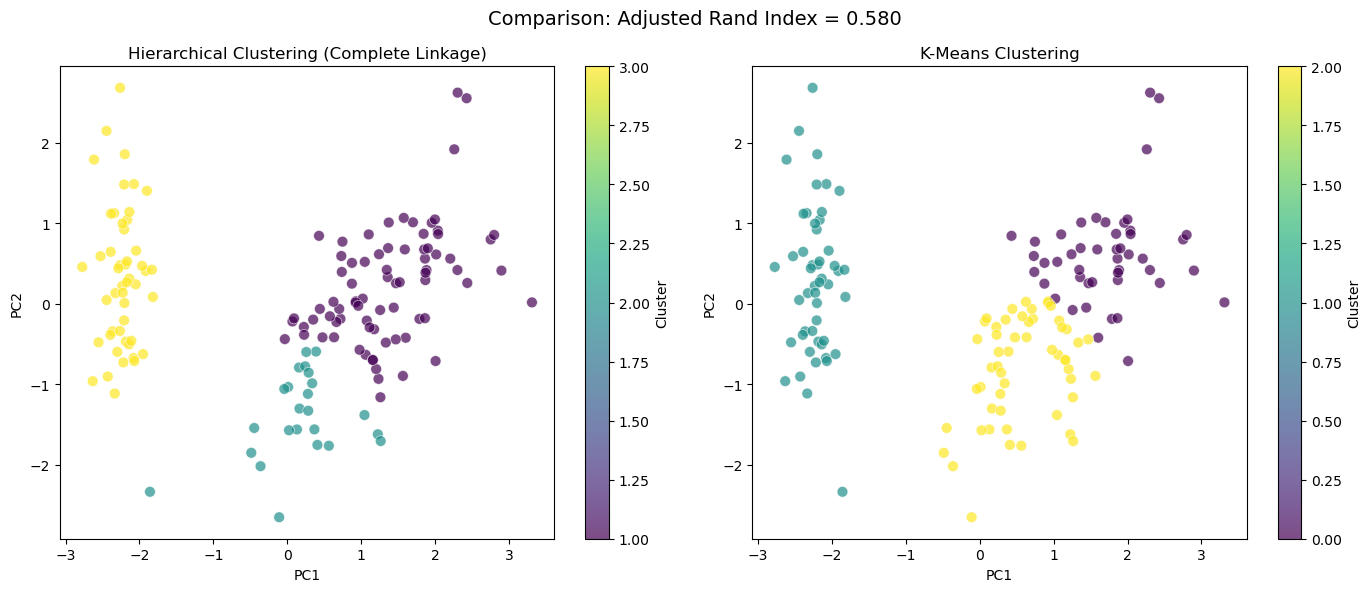

In [38]:
# Visualize K-Means vs Hierarchical side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hierarchical clustering
scatter1 = axes[0].scatter(
    q8_pca_data[:, 0],
    q8_pca_data[:, 1],
    c=q6_labels,
    cmap="viridis",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
    s=60,
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Hierarchical Clustering (Complete Linkage)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# K-Means clustering
scatter2 = axes[1].scatter(
    q8_pca_data[:, 0],
    q8_pca_data[:, 1],
    c=q9_kmeans_labels,
    cmap="viridis",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
    s=60,
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("K-Means Clustering")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.suptitle(f"Comparison: Adjusted Rand Index = {q9_ari_score:.3f}", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Reusable Hierarchical Clustering Function *(10 points)*

Create a reusable function that performs hierarchical clustering and returns
comprehensive results including the linkage matrix, cluster labels, and
cluster statistics.

Store the results as:
- **`q10_hierarchical_analysis`**: The function you implement
- **`q10_result_complete`**: Result of calling the function with complete linkage
- **`q10_result_average`**: Result of calling the function with average linkage
- **`q10_better_linkage`**: Which linkage produces more balanced clusters ("complete" or "average")

In [41]:
# Grade Cell: Question 10
#
# Task: Implement a reusable hierarchical clustering analysis function
#
# Instructions:
# 1. Create a function that takes data, n_clusters, and linkage method as inputs
# 2. Compute linkage matrix and extract cluster labels
# 3. Return results as a dictionary
# 4. Test with complete and average linkage


def q10_hierarchical_analysis(data, n_clusters, method):
    Z = linkage(data, method = method)
    labels = fcluster(Z, t = n_clusters, criterion = 'maxclust')
    max_distance = float(Z[-1, 2])
    cluster_sizes = {int(label): int(count) 
                     for label, count in zip(*np.unique(labels, return_counts = True))}
    
    return {
        'method': method,
        'n_clusters': n_clusters,
        'linkage_matrix': Z,
        'labels': labels,
        'max_distance': max_distance,
        'cluster_sizes': cluster_sizes
    }

q10_result_complete = q10_hierarchical_analysis(q2_scaled_data, n_clusters = 3, method = 'complete')
q10_result_average = q10_hierarchical_analysis(q2_scaled_data, n_clusters = 3, method = 'average')

complete_std = np.std(list(q10_result_complete['cluster_sizes'].values()))
average_std = np.std(list(q10_result_average['cluster_sizes'].values()))

q10_better_linkage = 'complete' if complete_std < average_std else 'average'

In [42]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert callable(q10_hierarchical_analysis), (
    "q10_hierarchical_analysis should be a function."
)

# Test function output structure
test_result = q10_hierarchical_analysis(q2_scaled_data, n_clusters=2, method="single")
assert isinstance(test_result, dict), "Function should return a dictionary."
assert "method" in test_result, "Result should contain 'method'."
assert "n_clusters" in test_result, "Result should contain 'n_clusters'."
assert "linkage_matrix" in test_result, "Result should contain 'linkage_matrix'."
assert "labels" in test_result, "Result should contain 'labels'."
assert "max_distance" in test_result, "Result should contain 'max_distance'."
assert "cluster_sizes" in test_result, "Result should contain 'cluster_sizes'."

# Test complete result
assert isinstance(q10_result_complete, dict), "q10_result_complete must be a dictionary."
assert q10_result_complete["method"] == "complete", (
    "q10_result_complete should use 'complete' linkage."
)
assert q10_result_complete["n_clusters"] == 3, (
    "q10_result_complete should have n_clusters=3."
)
assert len(q10_result_complete["labels"]) == q1_n_samples, (
    "Labels should match sample count."
)

# Test average result
assert isinstance(q10_result_average, dict), "q10_result_average must be a dictionary."
assert q10_result_average["method"] == "average", (
    "q10_result_average should use 'average' linkage."
)

# Test better_linkage
assert isinstance(q10_better_linkage, str), "q10_better_linkage must be a string."
assert q10_better_linkage in ["complete", "average"], (
    "q10_better_linkage should be 'complete' or 'average'."
)

print("Complete linkage results:")
print(f"  Max distance: {q10_result_complete['max_distance']}")
print(f"  Cluster sizes: {q10_result_complete['cluster_sizes']}")
print("\nAverage linkage results:")
print(f"  Max distance: {q10_result_average['max_distance']}")
print(f"  Cluster sizes: {q10_result_average['cluster_sizes']}")
print(f"\nMore balanced clusters: {q10_better_linkage}")

Complete linkage results:
  Max distance: 6.5293233125454835
  Cluster sizes: {1: 77, 2: 24, 3: 49}

Average linkage results:
  Max distance: 3.6601333340985196
  Cluster sizes: {1: 50, 2: 3, 3: 97}

More balanced clusters: complete


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.

**Key Takeaways from This Lab:**

- **Hierarchical clustering** builds a tree of nested clusters without
  specifying K upfront
- **Linkage criteria** (single, complete, average) dramatically affect
  dendrogram structure
- **Dendrograms** visualize the merge history and help identify natural
  cluster separations
- **Cutting dendrograms** at different heights produces different
  cluster granularities
- **Cluster profiling** reveals what makes each cluster distinct
- **Comparing with K-Means** using metrics like ARI helps validate
  clustering results

In many real-world scenarios, using both hierarchical clustering and
K-Means together provides complementary insights into data structure!